#Data dictionary (Features of each customer)
RowNumber: The sequential number assigned to each row in the dataset.

CustomerId: A unique identifier for each customer.

Surname: The surname of the customer.

CreditScore: The credit score of the customer.

Geography: The geographical location of the customer (e.g., country or region).

Gender: The gender of the customer.

Age: The age of the customer.

Tenure: The number of years the customer has been with the bank.

Balance: The account balance of the customer.

NumOfProducts: The number of bank products the customer has.

HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).

IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).

EstimatedSalary: The estimated salary of the customer.

Exited: Indicates whether the customer has exited the bank (binary: yes = 1 / no = 0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)

df = pd.read_csv('Churn_Modelling.csv')
display(df.head(10))

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [2]:
# Deleting unnecessary column
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [3]:
# Checking datatypes
display(df.dtypes)

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [4]:
# List of columns to be converted to 'category' type
category_columns = ['Geography',
                    'Gender',
                    'HasCrCard',
                    'IsActiveMember',
                    'Exited']

# Convert each of above columns to 'category' type
for column in category_columns:
  df[column] = df[column].astype('category')

In [5]:
# Checking datatypes after changes
display(df.dtypes)

,0
CreditScore,int64
Geography,category
Gender,category
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,category
IsActiveMember,category
EstimatedSalary,float64


,Retainers,Churners
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


,Retainers,Churners
Geography,,
France,83.85%,16.15%
Germany,67.56%,32.44%
Spain,83.33%,16.67%


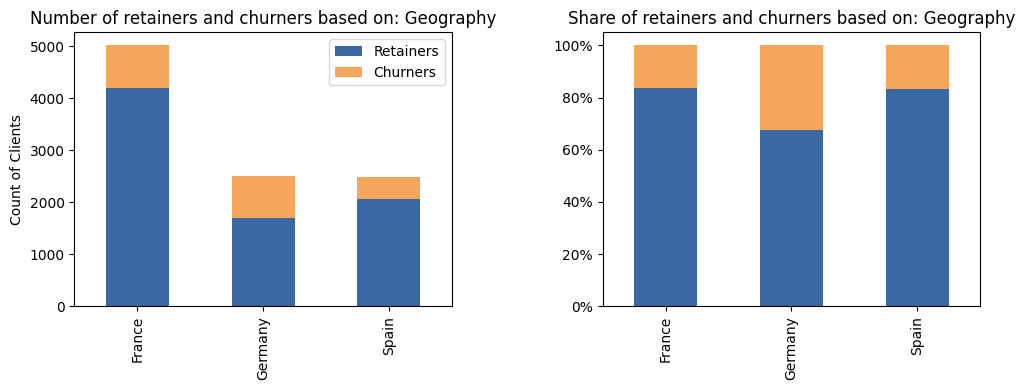

,Retainers,Churners
Gender,,
Female,3404,1139
Male,4559,898


,Retainers,Churners
Gender,,
Female,74.93%,25.07%
Male,83.54%,16.46%


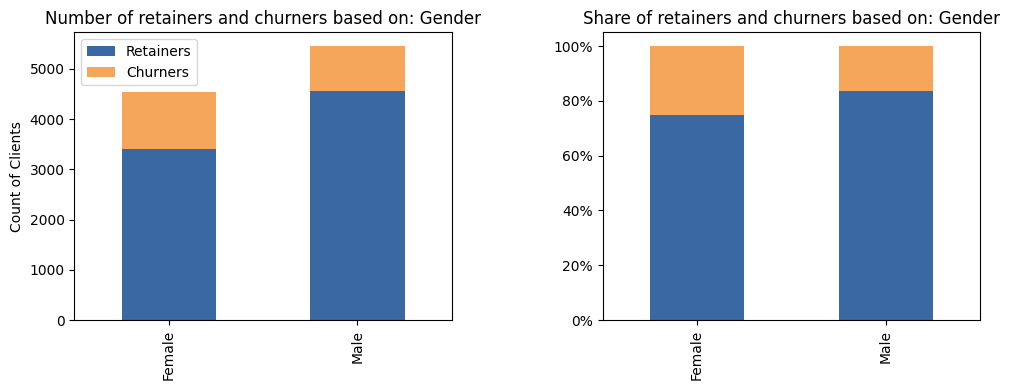

,Retainers,Churners
HasCrCard,,
0,2332,613
1,5631,1424


,Retainers,Churners
HasCrCard,,
0,79.19%,20.81%
1,79.82%,20.18%


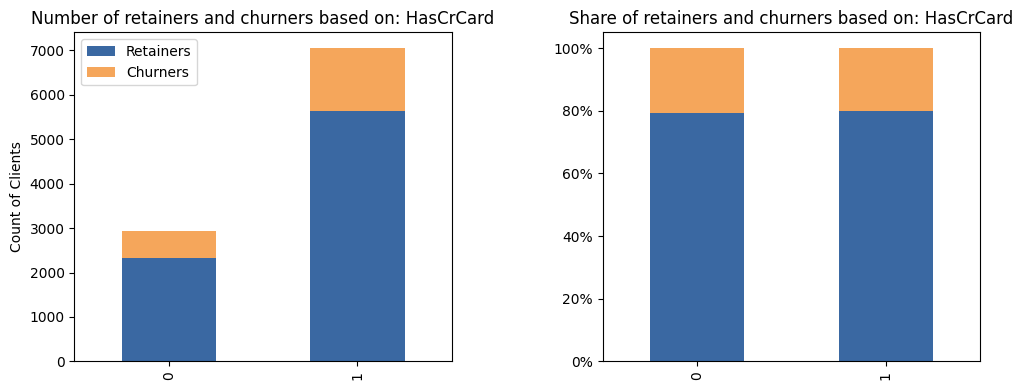

,Retainers,Churners
IsActiveMember,,
0,3547,1302
1,4416,735


,Retainers,Churners
IsActiveMember,,
0,73.15%,26.85%
1,85.73%,14.27%


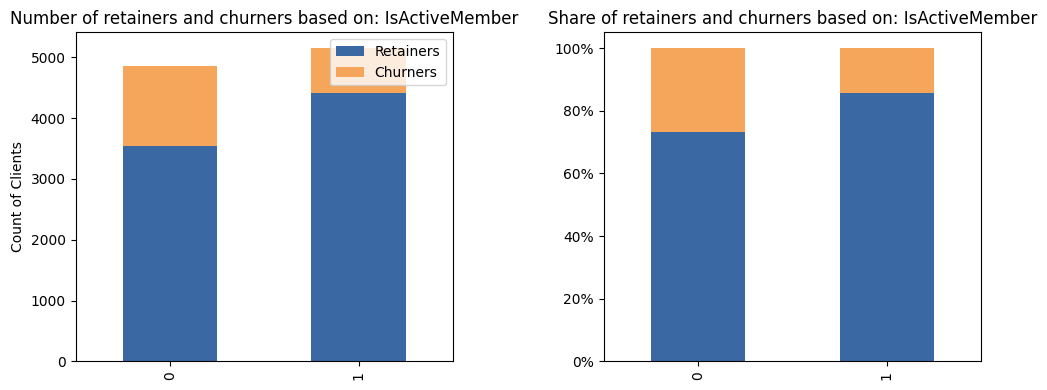

,Retainers,Churners
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


,Retainers,Churners
NumOfProducts,,
1,72.29%,27.71%
2,92.42%,7.58%
3,17.29%,82.71%
4,0.00%,100.00%


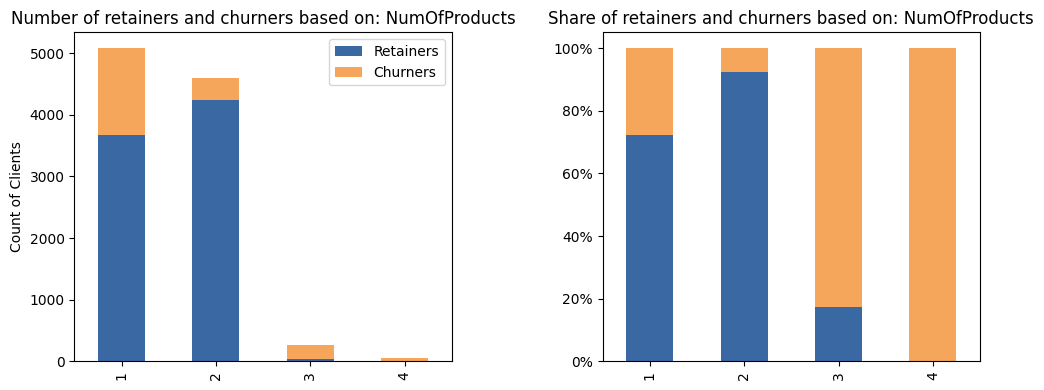

In [6]:
# Analyzing customer churn based on categorical features and NumOfProducts

from matplotlib.ticker import PercentFormatter

selected_features = ['Geography',
                     'Gender',
                     'HasCrCard',
                     'IsActiveMember',
                     'NumOfProducts']

for feature in selected_features:
  # Creating crosstab
  Category_crosstab = pd.crosstab(df[feature], df['Exited'])
  Category_crosstab.columns = ['Retainers', 'Churners']
  display(Category_crosstab)

  # Creating crosstab with normalization
  Category_crosstab_norm = pd.crosstab(df[feature], df['Exited'], normalize='index')
  Category_crosstab_norm = Category_crosstab_norm.map(lambda x: f'{x:.2%}')
  Category_crosstab_norm.columns = ['Retainers', 'Churners']
  display(Category_crosstab_norm)

  # Creating the figure and two axes
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))

  # Subplot 1- clients count
  Category_crosstab.reset_index().plot(
      kind='bar',
      x=feature,
      stacked=True,
      color=['#3a68a2', '#f5a65b'],
      legend=True,
      ax=axes[0]
  )
  axes[0].set_title('Number of retainers and churners based on: {}'.format(feature))
  axes[0].set_xlabel(None)
  axes[0].set_ylabel('Count of Clients')

  # Subplot 2- clients share
  Category_crosstab_norm = Category_crosstab_norm.map(lambda x: float(x.strip('%')) / 100)
  Category_crosstab_norm.reset_index().plot(
      kind='bar',
      x=feature,
      stacked=True,
      color=['#3a68a2', '#f5a65b'],
      legend=False,
      ax=axes[1]
  )
  axes[1].set_title('Share of retainers and churners based on: {}'.format(feature))
  axes[1].set_xlabel(None)
  axes[1].yaxis.set_major_formatter(PercentFormatter(1))

  plt.tight_layout()
  plt.subplots_adjust(wspace=0.4)
  plt.show()

#Conclusions

*   All customers with 4 products are churners.



*   More than 80% of customers holding 3 products have churned.


*   Germany has the highest churn rate among all countries.




*   Active customers are significantly less likely to leave the bank compared to inactive customers.





In [7]:
# Read statistics
display(df.describe().round(2))

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,650.53,38.92,5.01,76485.89,1.53,100090.24
std,96.65,10.49,2.89,62397.41,0.58,57510.49
min,350.00,18.00,0.00,0.00,1.00,11.58
25%,584.00,32.00,3.00,0.00,1.00,51002.11
50%,652.00,37.00,5.00,97198.54,1.00,100193.92
75%,718.00,44.00,7.00,127644.24,2.00,149388.25
max,850.00,92.00,10.00,250898.09,4.00,199992.48


In [8]:
# Checking Nans
print("\nNan values per column:")
display(df.isna().sum())


Nan values per column:


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [9]:
# Checking duplicates
duplicates = df.duplicated()
duplicate_count = duplicates.sum()
print('Number of duplicate rows:', duplicate_count)

Number of duplicate rows: 0


In [10]:
# Checking unique values per column
print('Unique values per column:\n\n', df.nunique())

Unique values per column:

 CreditScore         460
Geography             3
Gender                2
Age                  70
Tenure               11
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    9999
Exited                2
dtype: int64


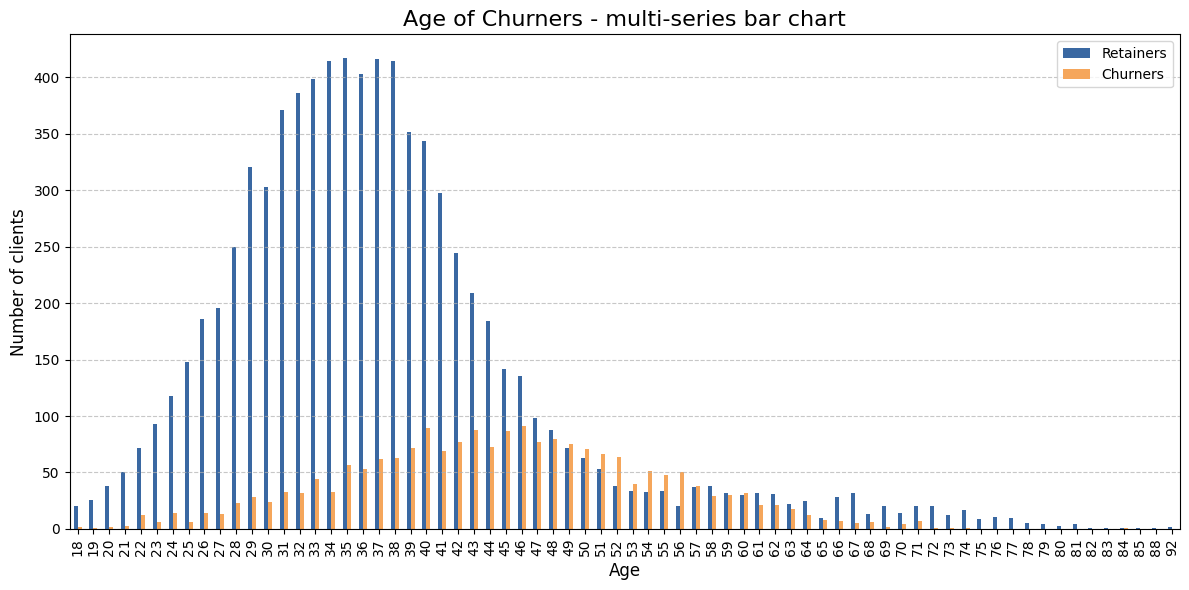

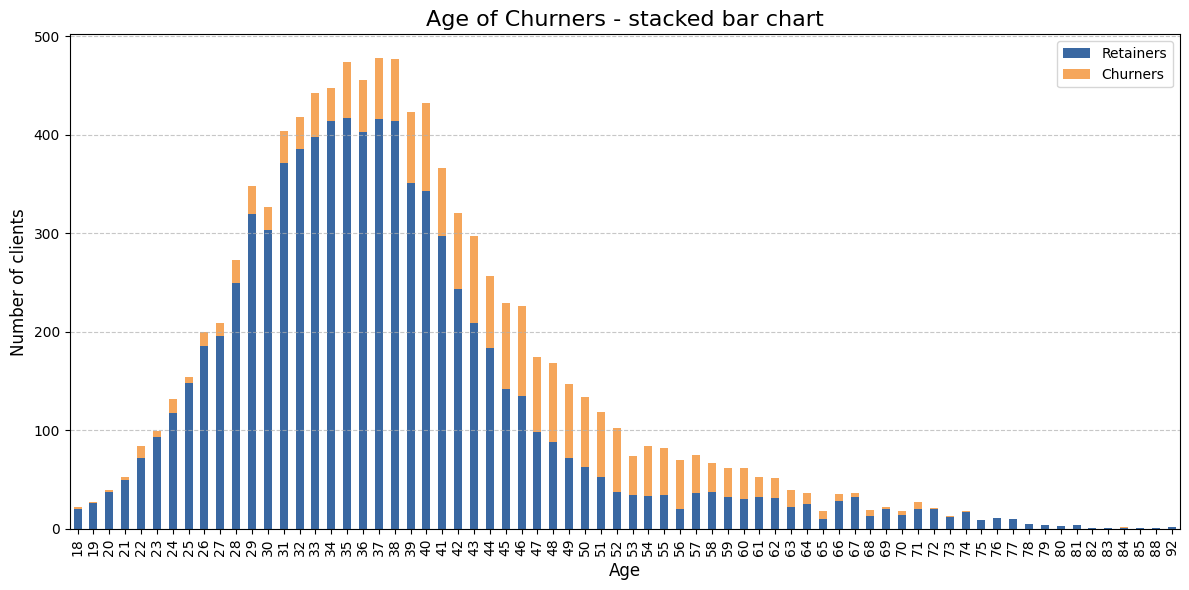

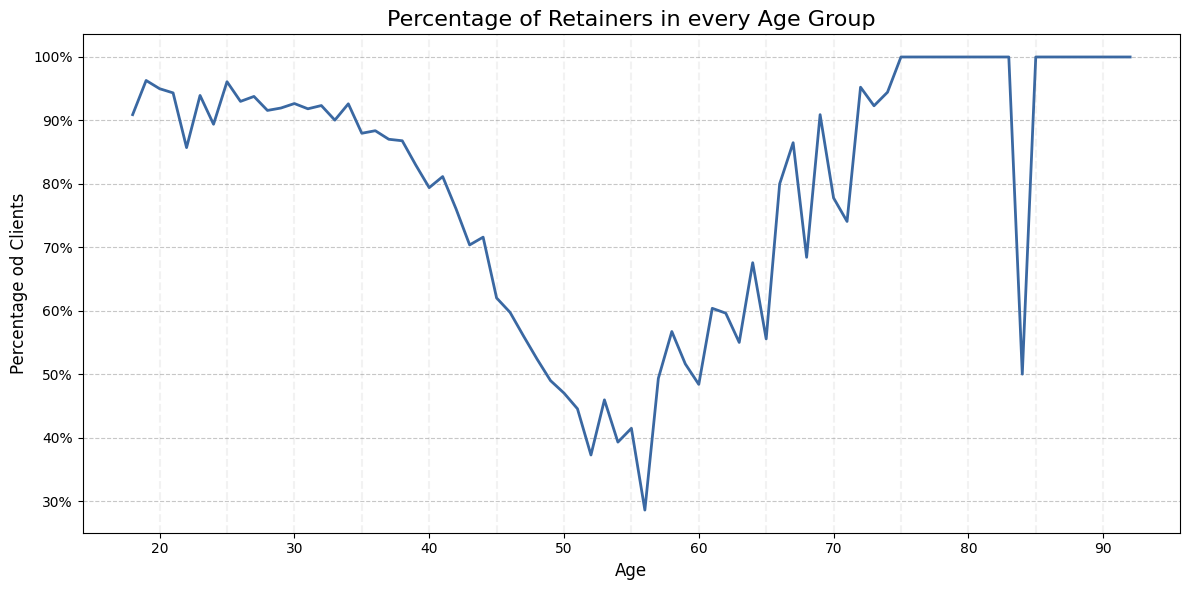

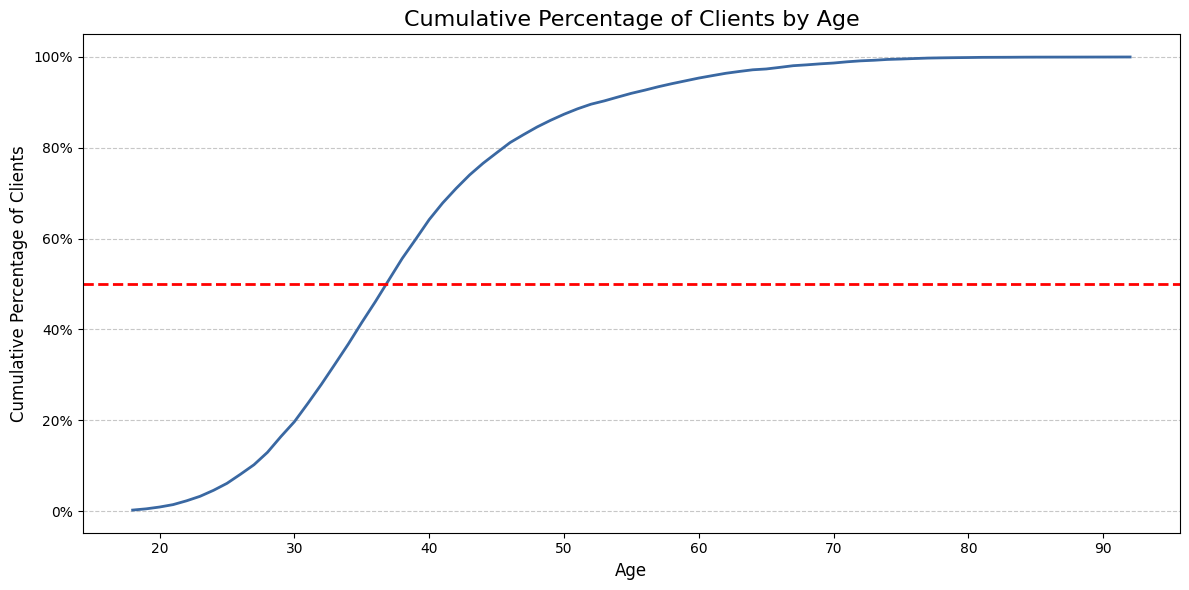

In [11]:
# Selective analysis of features: Age

# Grouping data
grouped = df.groupby(['Age', 'Exited'], observed=True).size().unstack(fill_value=0)

# Creating plot 1
grouped.plot(
    kind='bar',
    stacked=False,
    figsize=(12, 6),
    color=['#3a68a2', '#f5a65b']
)
plt.title('Age of Churners - multi-series bar chart', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend(['Retainers', 'Churners'], fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Creating plot 2
grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#3a68a2', '#f5a65b']
)
plt.title('Age of Churners - stacked bar chart', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend(['Retainers', 'Churners'], fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Creating plot 3
# Normalize the data to show percentages
grouped_percentage = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Creating line plot for percentage of Retainers
ax = grouped_percentage[0].plot(
    kind='line',
    figsize=(12, 6),
    color='#3a68a2',
    linewidth=2
)

# Adding title and labels
plt.title('Percentage of Retainers in every Age Group', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Percentage od Clients', fontsize=12)

# Formatting the y-axis as percentage
ax.yaxis.set_major_formatter(PercentFormatter(100))

# Adding dashed vertical lines at every 5 units on the x-axis
for i in range(20, max(grouped_percentage.index), 5):
  plt.axvline(x=i, color='gray', linestyle='--', alpha=0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# Creating plot 4
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Grouping data by age
age_grouped = df.groupby('Age').size()

# Normalize the data to get percentages
age_percentage = age_grouped / age_grouped.sum() * 100

# Calculate cumulative percentage
cumulative_percentage = age_percentage.cumsum()

# Creating the cumulative percentage plot
plt.figure(figsize=(12, 6))
cumulative_percentage.plot(kind='line', color='#3a68a2', linewidth=2)

# Adding title and labels
plt.title('Cumulative Percentage of Clients by Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Cumulative Percentage of Clients', fontsize=12)

# Format the y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding a horizontal dashed line at 50%
plt.axhline(y=50, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

plt.show()

In [12]:
# Calculating the boundary age for the youngest 50% of clients
boundary_age = df['Age'].quantile(0.5)

# Displaying the boundary age
print(f'Boundary age for the youngest 50% of clients: {boundary_age}')

Boundary age for the youngest 50% of clients: 37.0


#Conclusions


*   The median age of customers is 37 (50% of clients are younger than 37).



*   After the age of 37, the proportion of retained customers decreases significantly.


*   Customers aged between 49 and 57 show the highest churn rates.




*   Clients over 60 are mostly retainers; however, this age group represents only a small portion of the total customer base.





#Distribution Analysis of Numerical Features





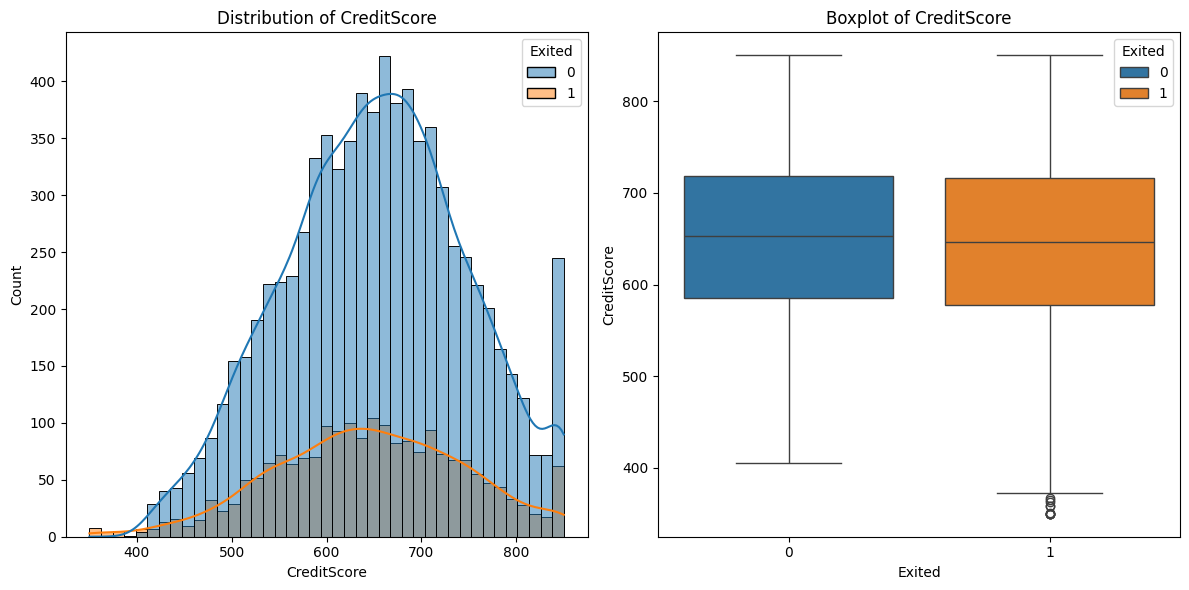

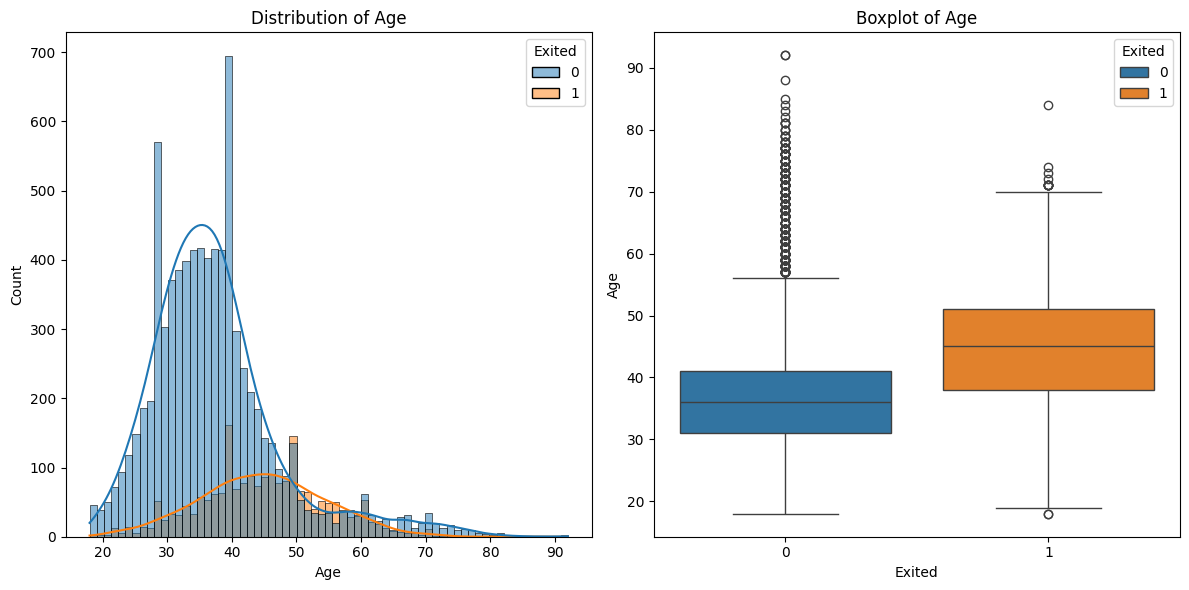

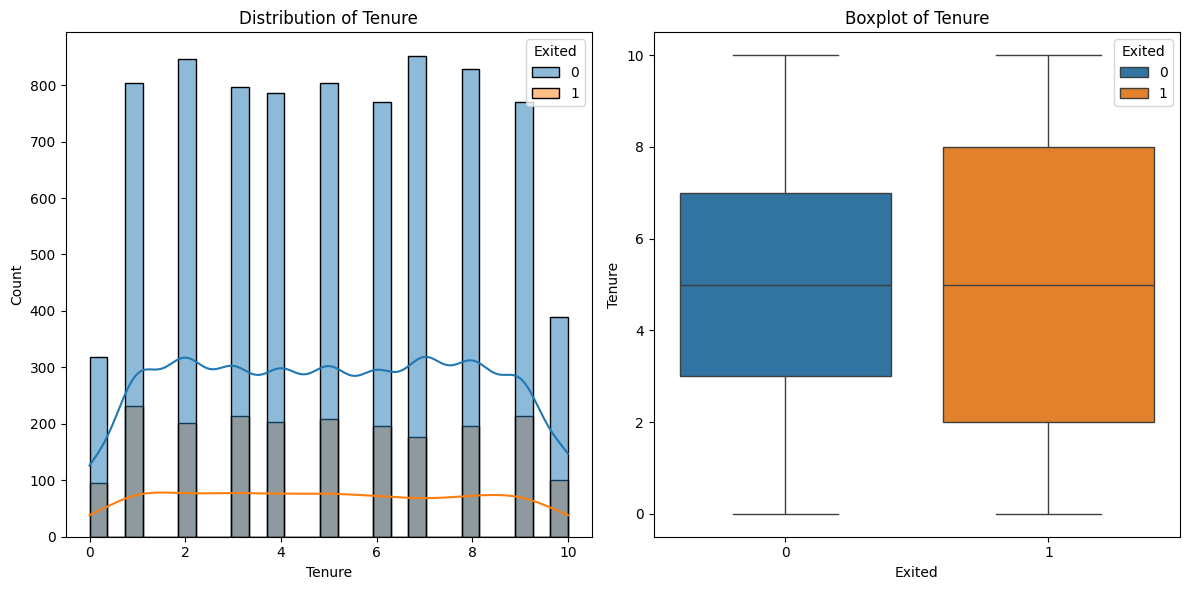

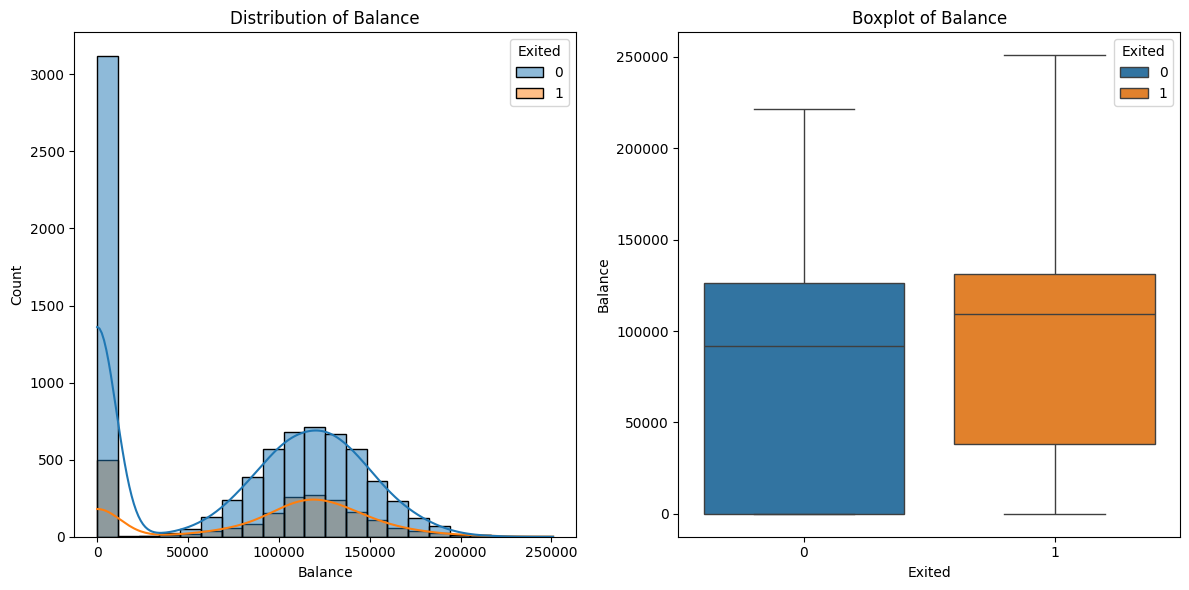

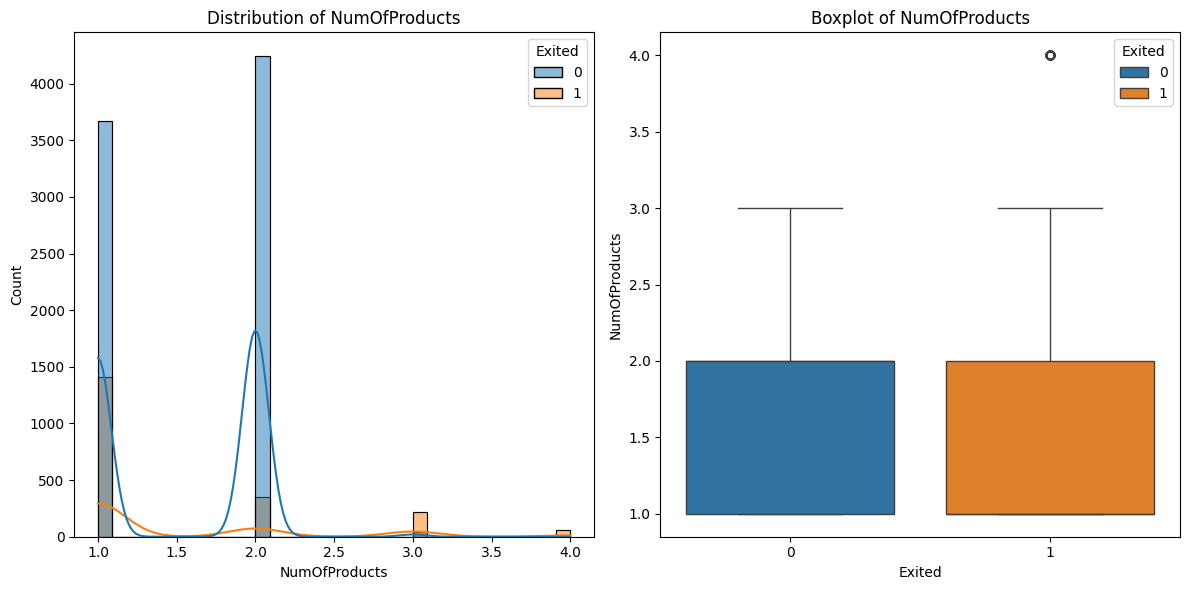

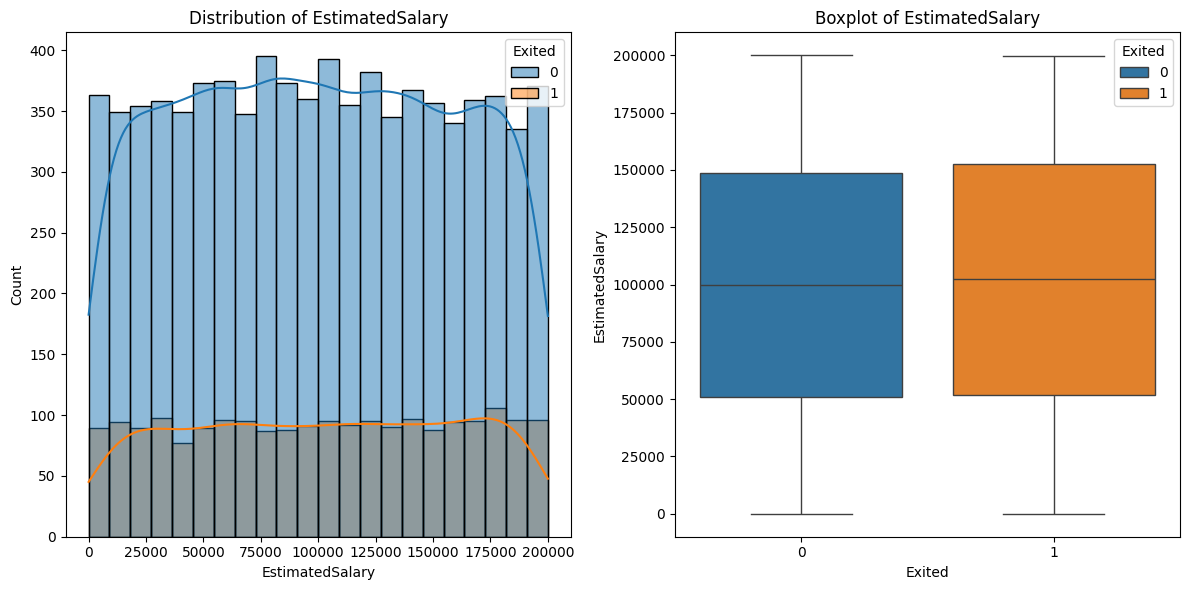

In [13]:
# Selection of numerical columns
df_numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Visualization of distributions
for column in df_numeric_columns:
  plt.figure(figsize=(12, 6))

  # Distribution with distplot
  plt.subplot(1, 2, 1)
  sns.histplot(data=df, x=column, kde=True, hue='Exited')
  plt.title(f'Distribution of {column}')

  # Boxplot to identify outliers
  plt.subplot(1, 2, 2)
  sns.boxplot(x='Exited', y=df[column], data=df, hue='Exited')
  plt.title(f'Boxplot of {column}')

  plt.tight_layout()
  plt.show()

##Conclusions


*   Estimated salary is roughly uniformly distributed between 0 and 200,000 (currency not specified).



*   Tenure exhibits a similar uniform distribution, indicating that this variable alone has limited impact on customer churn.



*   Account balance follows an approximately normal distribution with a mean around 120,000, accompanied by a notable secondary peak near zero.


*   Age distributions for both retained and churned customers are roughly normal; however, their peaks differ significantly — retainers peak around 37 years, while churners peak closer to 45 years.




*   Very few customers hold 3 or 4 products.







#Visualizing Relationships Between Features with Pairplots (Categorized by Churn Status)



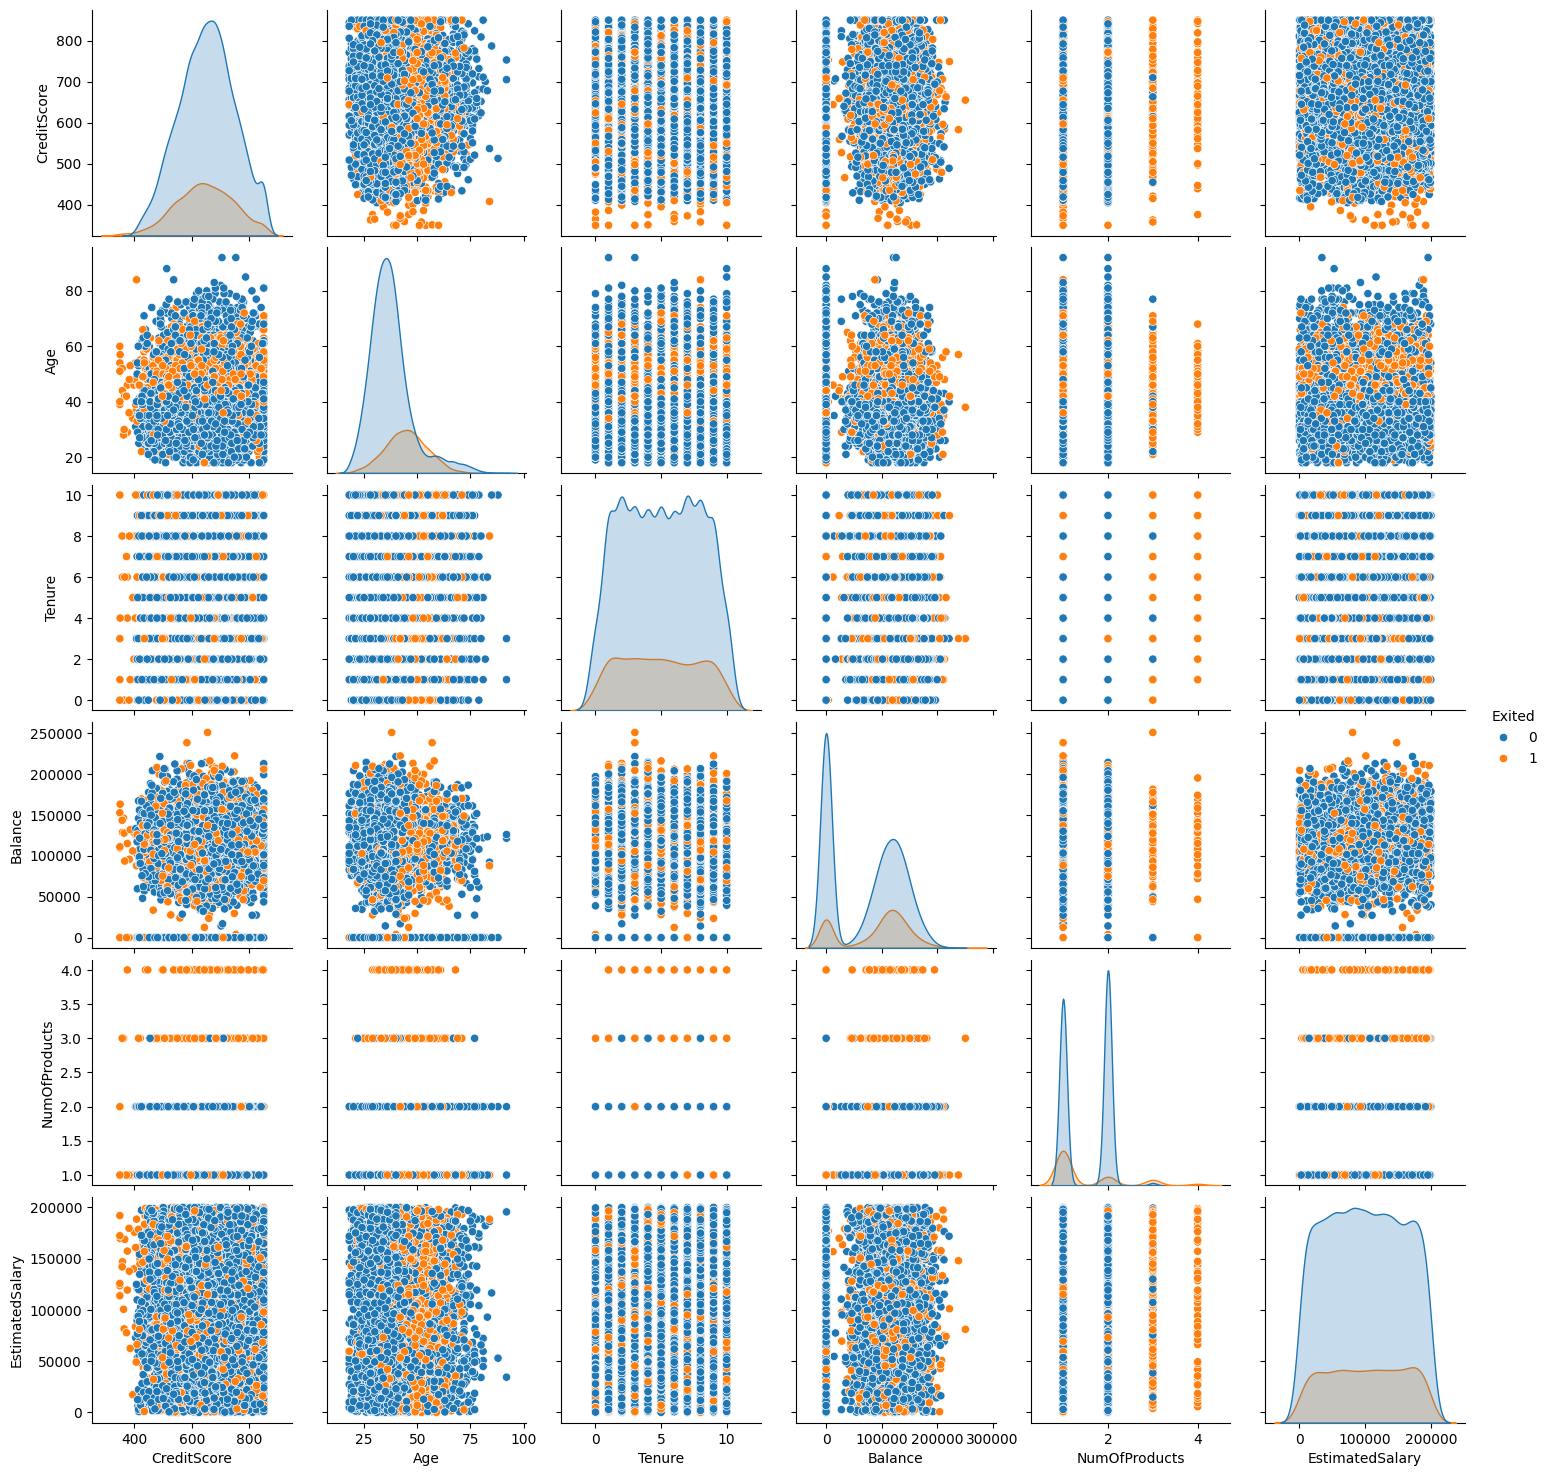

In [14]:
# Creating pairplot
pairplot = sns.pairplot(df, hue='Exited', diag_kws={'common_norm': True})
pairplot.savefig('pairplot.png')

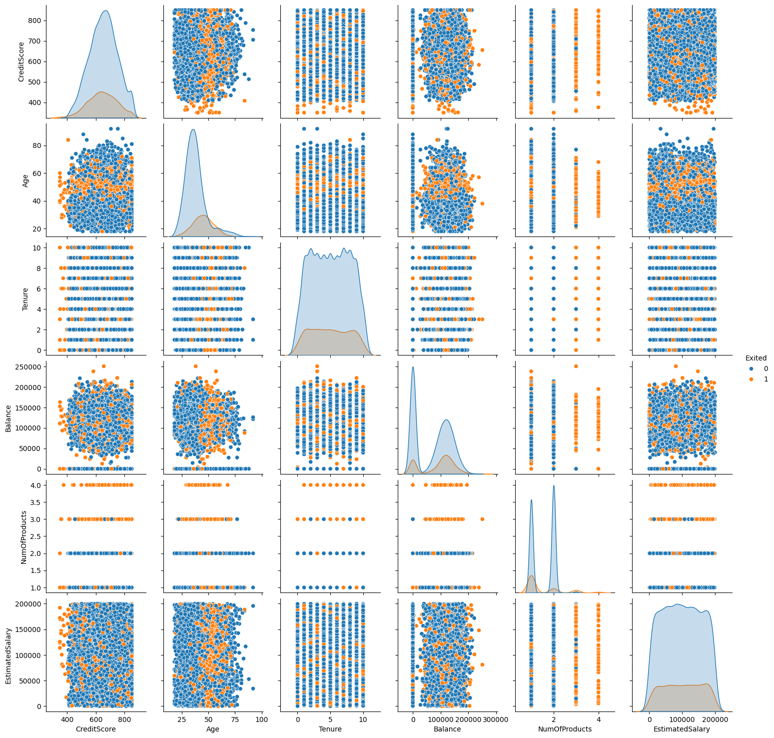

In [15]:
# Loading the pairplot image
from PIL import Image

img = Image.open('pairplot.png')
img_resized = img.resize((img.width // 2, img.height // 2))
display(img_resized)

#Correlations

<Axes: >

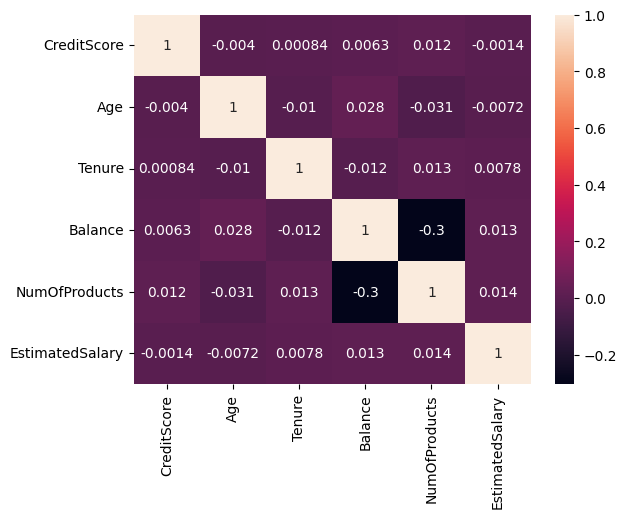

In [16]:
# Selecting numerical columns
numerical_df = df.select_dtypes(include=['float64', 'int64', 'int8'])

# Correlation visualization
sns.heatmap(numerical_df.corr(), annot=True)

In [17]:
numerical_df.corr().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.00
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,0.01
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.01
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,1.00


#Checking the Class Distribution of the Target Variable



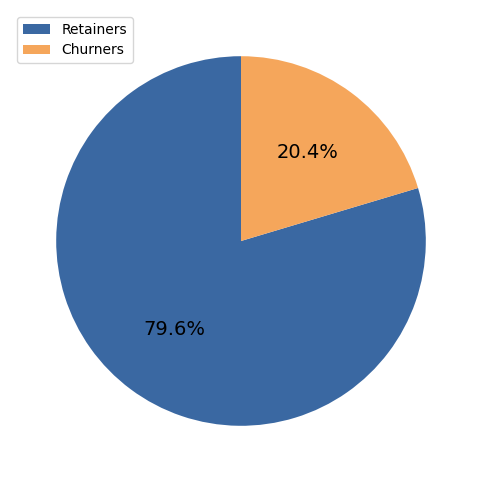

In [19]:
# Target data
crosstab = pd.crosstab(index=df['Exited'], columns='count', normalize='columns')
pie_data = crosstab['count']
labels = ['Retainers', 'Churners']

# Pie chart
plt.figure(figsize=(6, 6))
colors = ['#3a68a2', '#f5a65b']
plt.pie(
    pie_data,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 14}
)
plt.legend(labels, loc='upper left')
plt.show()

##Summary of EDA


*   The target variable (Exited) is significantly imbalanced, with approximately 80% retained customers and 20% churners.



*   No significant outliers or invalid values were detected in the dataset.


*   The generally weak correlations between features may be attributed to the synthetic nature of the dataset.




*   Customer age emerges as one of the most influential variables for predicting churn.



